<a href="https://colab.research.google.com/github/dhruvohri07-web/Markint-campaign-analytics/blob/main/maeketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Cleaning & Feature Engineering

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/marketing_data.csv")

# Total customer spend
df["Total_Spend"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

# Total purchases across channels
df["Total_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

# Average order value
df["Avg_Order_Value"] = df["Total_Spend"] / df["Total_Purchases"].replace(0,1)

# Customer lifetime value estimate
df["CLV"] = df["Avg_Order_Value"] * df["Total_Purchases"] * 2

# Age
df["Age"] = 2024 - df["Year_Birth"]

# Save processed dataset
df.to_csv("processed_marketing_data.csv", index=False)

print("Data preprocessing complete.")

Data preprocessing complete.


RFM Customer Segmentation

In [2]:
import pandas as pd

df = pd.read_csv("processed_marketing_data.csv")

# Recency
recency = df["Recency"]

# Frequency
frequency = df["Total_Purchases"]

# Monetary
monetary = df["Total_Spend"]

df["R_score"] = pd.qcut(recency, 4, labels=[4,3,2,1])
df["F_score"] = pd.qcut(frequency.rank(method="first"), 4, labels=[1,2,3,4])
df["M_score"] = pd.qcut(monetary, 4, labels=[1,2,3,4])

df["RFM"] = df["R_score"].astype(str) + df["F_score"].astype(str) + df["M_score"].astype(str)

print(df[["ID","RFM"]].head())

      ID  RFM
0   1826  434
1      1  433
2  10476  422
3   1386  411
4   5371  412


Campaign Performance Analysis

In [3]:
campaigns = df[
[
"AcceptedCmp1",
"AcceptedCmp2",
"AcceptedCmp3",
"AcceptedCmp4",
"AcceptedCmp5",
"Response"
]
].sum()

print(campaigns)

AcceptedCmp1    144
AcceptedCmp2     30
AcceptedCmp3    163
AcceptedCmp4    167
AcceptedCmp5    163
Response        334
dtype: int64


visualization

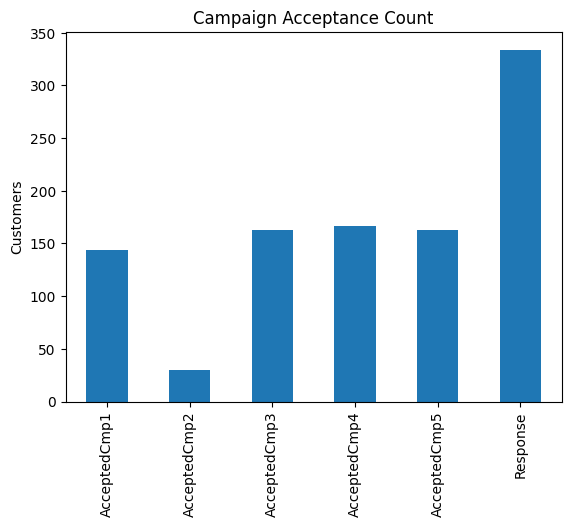

In [4]:
import matplotlib.pyplot as plt

campaigns.plot(kind="bar")
plt.title("Campaign Acceptance Count")
plt.ylabel("Customers")
plt.show()

Marketing Channel Analysis

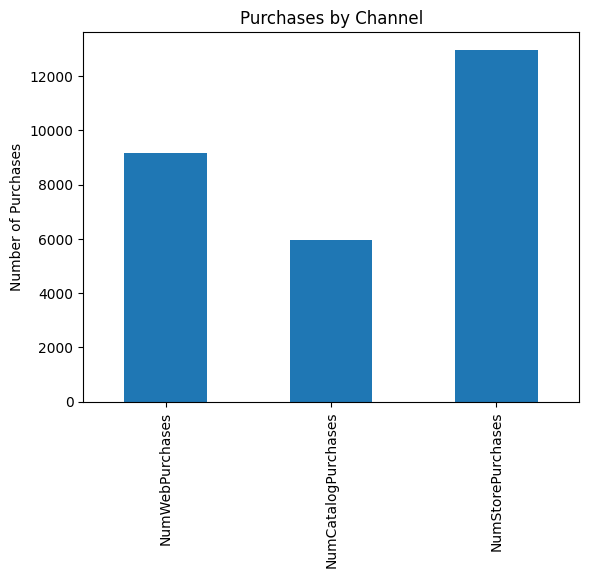

In [5]:
channel_data = df[
["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]
].sum()

channel_data.plot(kind="bar")

plt.title("Purchases by Channel")
plt.ylabel("Number of Purchases")
plt.show()

Customer Spending Analysis

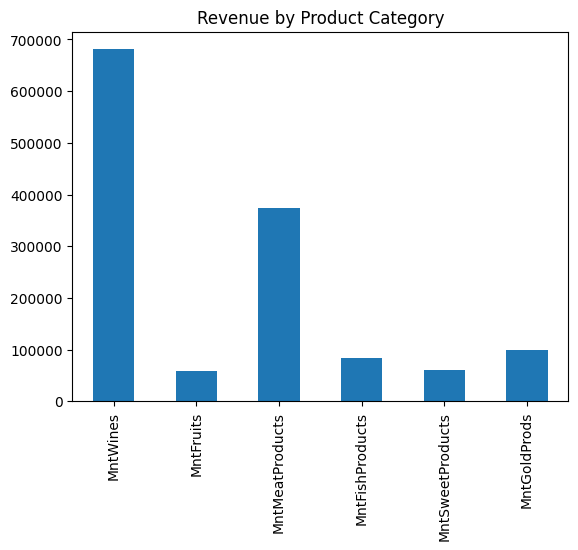

In [6]:
products = df[
[
"MntWines",
"MntFruits",
"MntMeatProducts",
"MntFishProducts",
"MntSweetProducts",
"MntGoldProds"
]
].sum()

products.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.show()

Campaign Response Prediction (Machine Learning)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Clean the 'Income' column by removing non-numeric characters and converting to float
df['Income'] = df['Income'].replace({r'\$': '', r',': '', r' ': ''}, regex=True).astype(float)

features = [
"Income",
"Recency",
"Total_Spend",
"Total_Purchases",
"NumWebVisitsMonth"
]

X = df[features]
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8482142857142857


<Axes: xlabel='Income', ylabel='Total_Spend'>

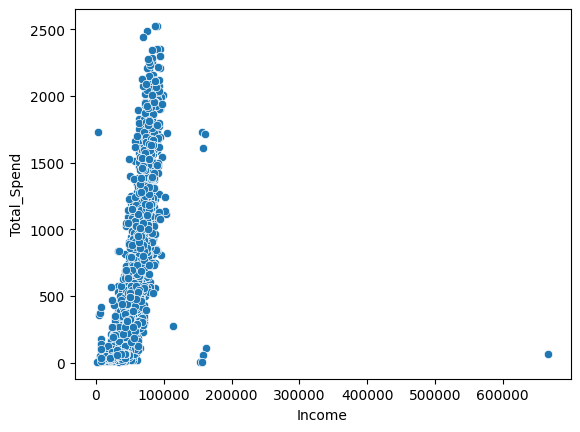

In [9]:
import seaborn as sns

sns.scatterplot(x="Income", y="Total_Spend", data=df)

Age vs Spending

<Axes: xlabel='Age', ylabel='Total_Spend'>

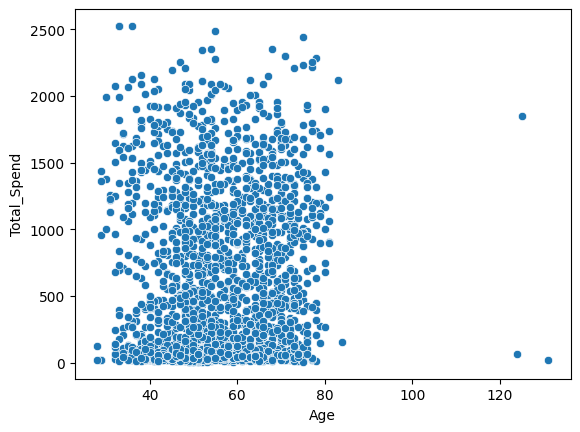

In [10]:
sns.scatterplot(x="Age", y="Total_Spend", data=df)

Campaign response rate

<Axes: ylabel='count'>

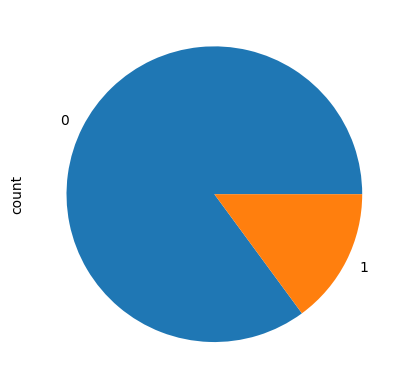

In [11]:
df["Response"].value_counts().plot(kind="pie")